In [ ]:
# Chemical Reactor Yield Prediction
### Machine Learning Competition Notebook

Author: Tushar Kumar Mishra

Goal:
Predict overall_yield using reactor operating parameters.

In [1]:
# ================================
# Import Required Libraries
# ================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option("display.max_columns", None)

print("Libraries Imported Successfully!")

Libraries Imported Successfully!


In [2]:
# ================================
# Load Training Dataset
# ================================

df = pd.read_csv("train_dataset.csv")

print("Dataset Loaded Successfully!")

df.head()

Dataset Loaded Successfully!


,flow_rate_L_min,concentration_mol_L,inlet_temperature_K,length_m,jacket_temperature_K,overall_yield
0,33.09,3.68,357.75,19.87,383.79,63.024
1,76.30,1.34,429.70,14.84,405.72,86.611
2,59.90,1.01,431.10,11.76,385.40,86.347
3,49.90,2.21,445.61,22.85,367.74,92.175
4,16.70,3.95,458.91,4.56,374.13,82.211


In [4]:
# =====================================
# Basic Information About Dataset
# =====================================

print("Shape of Dataset :", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

Shape of Dataset : (150, 6)

Column Names:
['flow_rate_L_min', 'concentration_mol_L', 'inlet_temperature_K', 'length_m', 'jacket_temperature_K', 'overall_yield']

Data Types:
flow_rate_L_min         float64
concentration_mol_L     float64
inlet_temperature_K     float64
length_m                float64
jacket_temperature_K    float64
overall_yield           float64
dtype: object


In [5]:
# =====================================
# Statistical Summary
# =====================================

df.describe().T

,count,mean,std,min,25%,50%,75%,max
flow_rate_L_min,150.0,40.466800,22.239772,5.41,21.1125,38.610,61.2275,79.020
concentration_mol_L,150.0,2.311333,1.019844,0.52,1.3625,2.445,3.1550,3.970
inlet_temperature_K,150.0,424.423400,45.200641,351.63,387.2550,425.630,462.9725,498.580
length_m,150.0,14.086533,6.995343,2.26,8.0275,14.235,20.6850,24.990
jacket_temperature_K,150.0,442.240800,55.047768,354.01,393.3275,437.080,486.1800,547.990
overall_yield,150.0,36.222173,38.427427,0.00,0.0135,15.314,74.8765,99.971


In [6]:
# =====================================
# Missing Values
# =====================================

missing = df.isnull().sum()

print(missing)

flow_rate_L_min         0
concentration_mol_L     0
inlet_temperature_K     0
length_m                0
jacket_temperature_K    0
overall_yield           0
dtype: int64


In [7]:
# =====================================
# Duplicate Rows
# =====================================

duplicates = df.duplicated().sum()

print("Duplicate Rows:", duplicates)

Duplicate Rows: 0


In [8]:
# =====================================
# Numerical Columns
# =====================================

numerical_columns = df.select_dtypes(include=np.number).columns

print(numerical_columns)

Index(['flow_rate_L_min', 'concentration_mol_L', 'inlet_temperature_K',
       'length_m', 'jacket_temperature_K', 'overall_yield'],
      dtype='object')


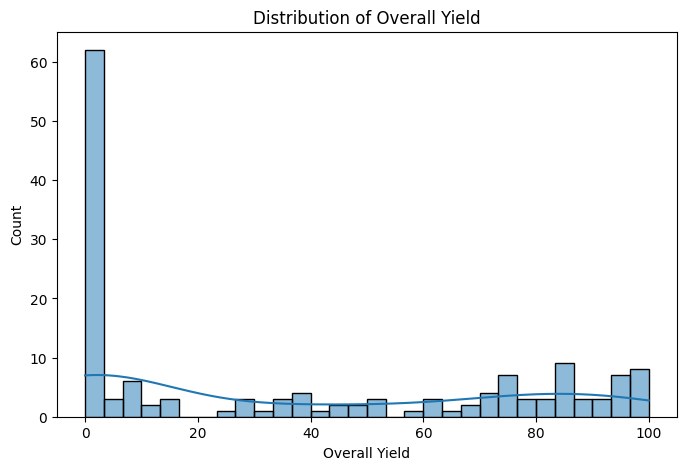

In [9]:
# =====================================
# Target Variable Distribution
# =====================================

plt.figure(figsize=(8,5))

sns.histplot(df["overall_yield"], bins=30, kde=True)

plt.title("Distribution of Overall Yield")
plt.xlabel("Overall Yield")
plt.ylabel("Count")

plt.show()

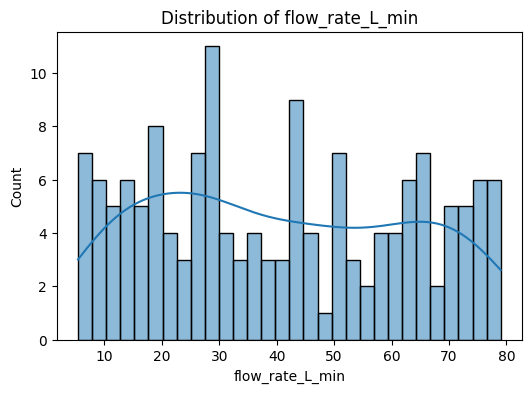

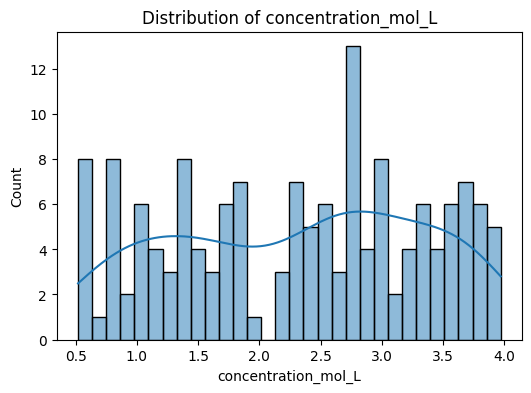

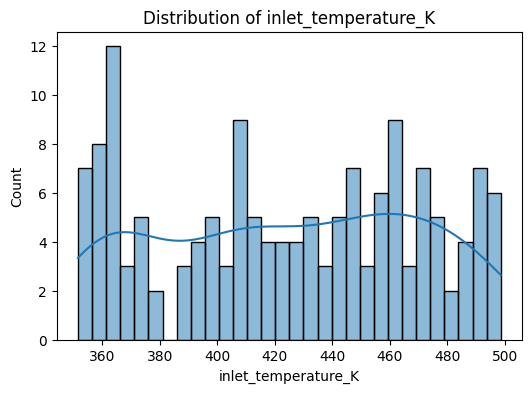

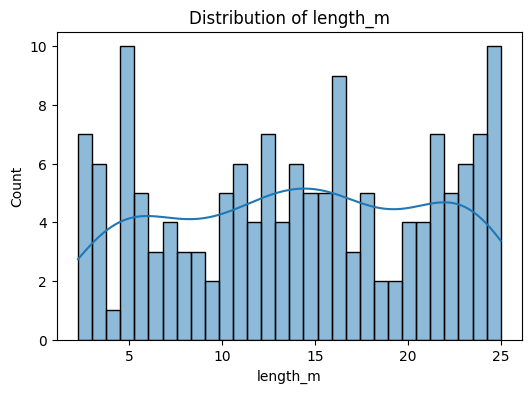

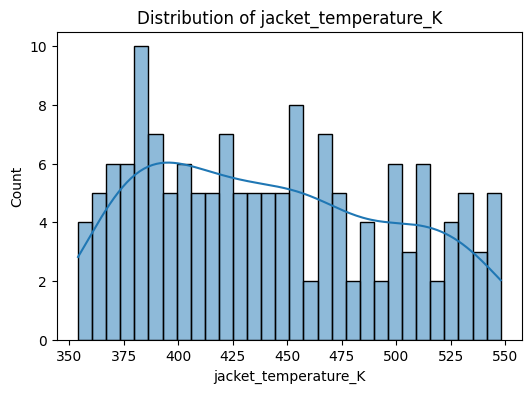

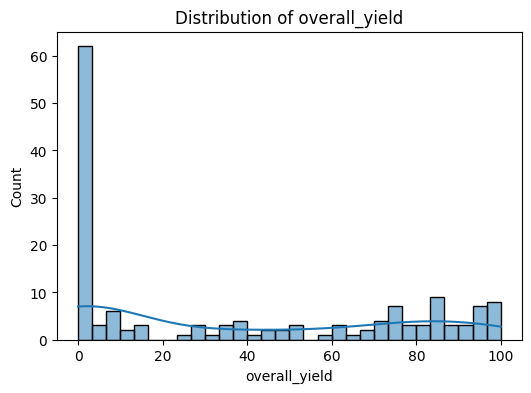

In [10]:
# =====================================
# Distribution of Numerical Features
# =====================================

numerical_columns = df.select_dtypes(include="number").columns

for column in numerical_columns:

    plt.figure(figsize=(6,4))

    sns.histplot(df[column], bins=30, kde=True)

    plt.title(f"Distribution of {column}")

    plt.show()

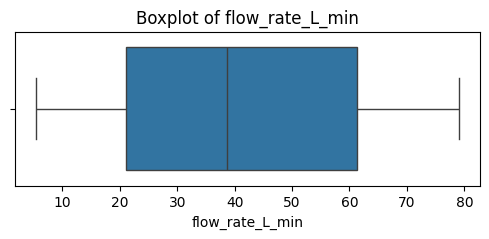

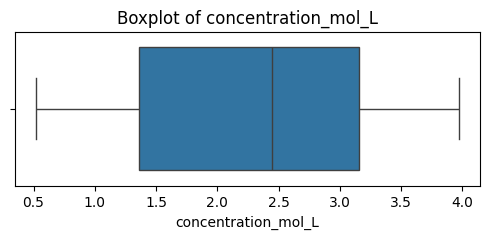

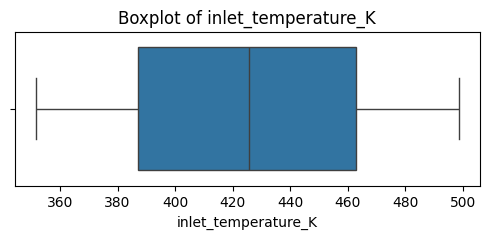

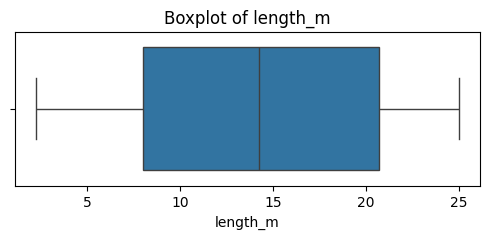

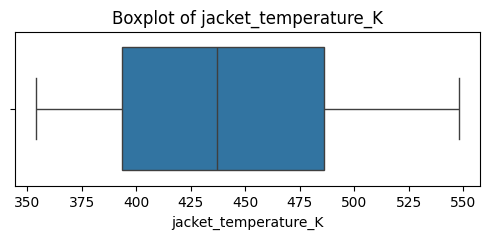

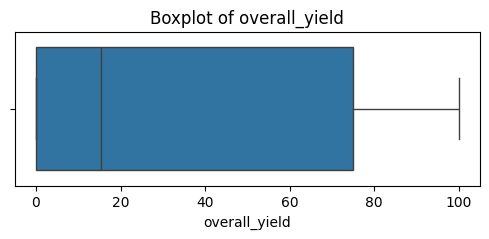

In [11]:
# =====================================
# Boxplots
# =====================================

for column in numerical_columns:

    plt.figure(figsize=(6,2))

    sns.boxplot(x=df[column])

    plt.title(f"Boxplot of {column}")

    plt.show()

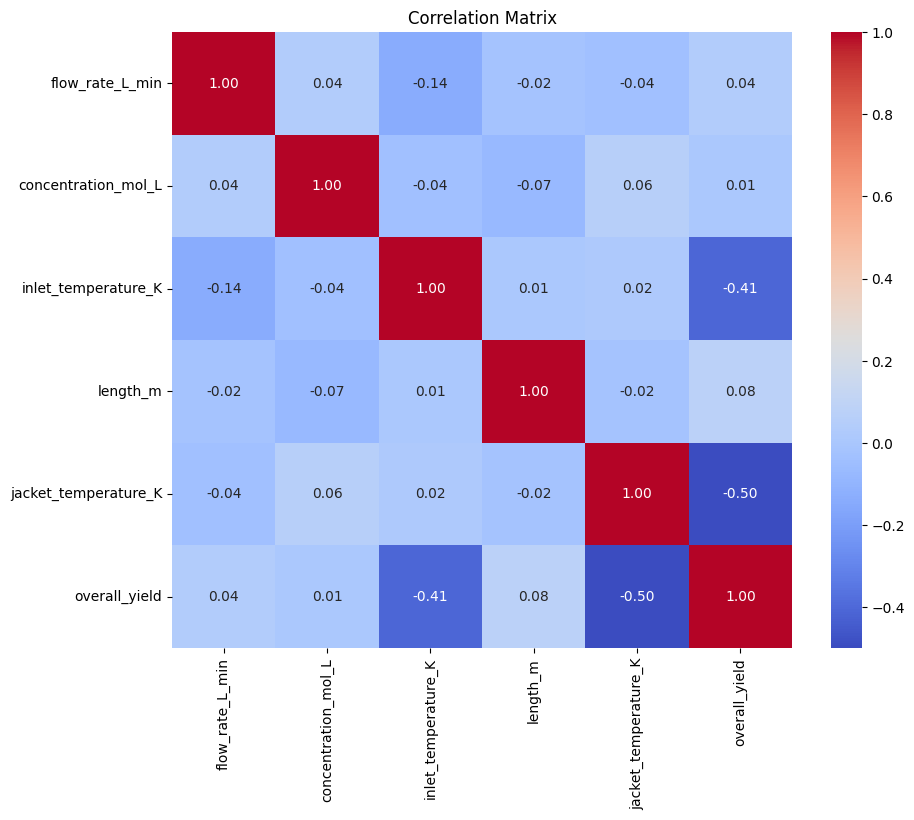

In [12]:
# =====================================
# Correlation Matrix
# =====================================

plt.figure(figsize=(10,8))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.show()

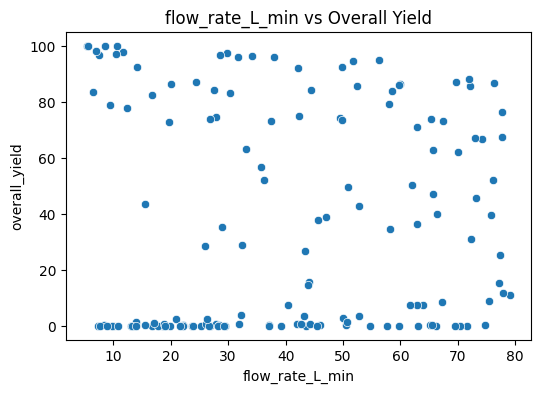

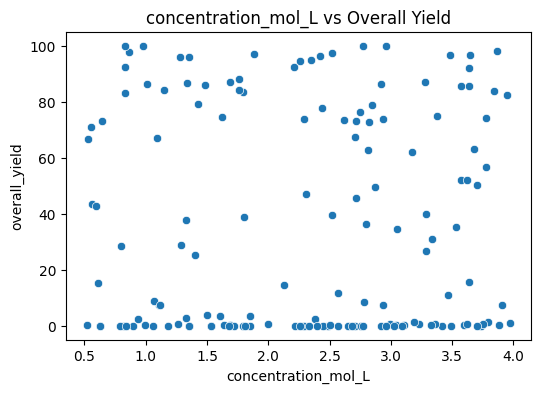

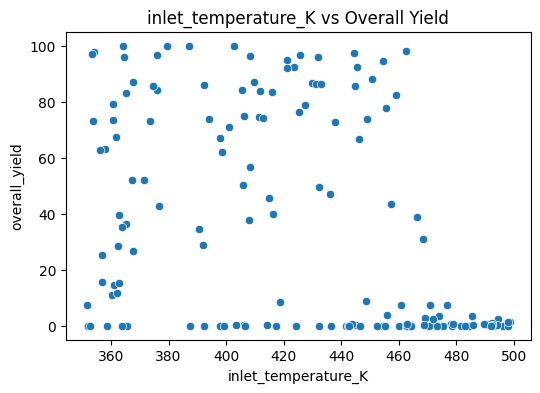

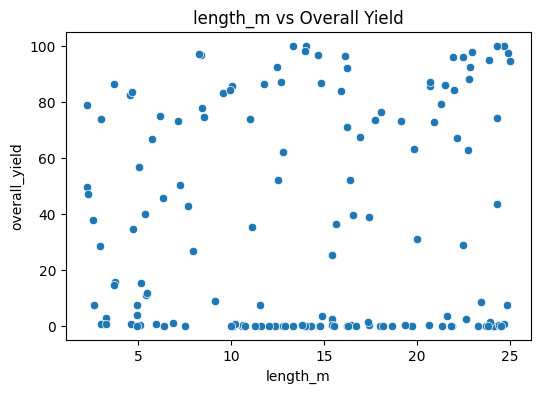

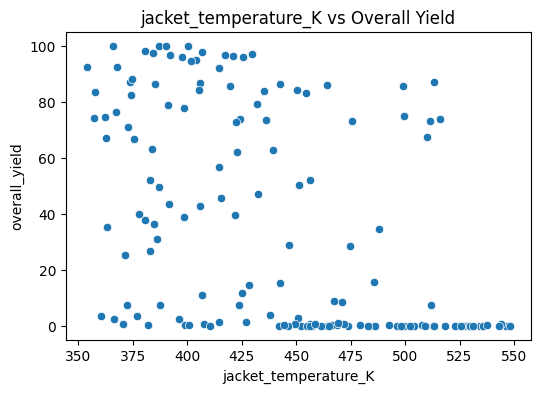

In [13]:
# =====================================
# Feature vs Target
# =====================================

features = [
    "flow_rate_L_min",
    "concentration_mol_L",
    "inlet_temperature_K",
    "length_m",
    "jacket_temperature_K"
]

for feature in features:

    plt.figure(figsize=(6,4))

    sns.scatterplot(
        data=df,
        x=feature,
        y="overall_yield"
    )

    plt.title(f"{feature} vs Overall Yield")

    plt.show()

In [14]:
# ==========================================
# Create a copy of the dataset
# ==========================================

df_fe = df.copy()

print("Feature Engineering Dataset Created")
df_fe.head()

Feature Engineering Dataset Created


,flow_rate_L_min,concentration_mol_L,inlet_temperature_K,length_m,jacket_temperature_K,overall_yield
0,33.09,3.68,357.75,19.87,383.79,63.024
1,76.30,1.34,429.70,14.84,405.72,86.611
2,59.90,1.01,431.10,11.76,385.40,86.347
3,49.90,2.21,445.61,22.85,367.74,92.175
4,16.70,3.95,458.91,4.56,374.13,82.211


In [15]:
# ==========================================
# Residence Index
# ==========================================

df_fe["Residence_Index"] = (
    df_fe["length_m"] /
    df_fe["flow_rate_L_min"]
)

df_fe[["length_m","flow_rate_L_min","Residence_Index"]].head()

,length_m,flow_rate_L_min,Residence_Index
0,19.87,33.09,0.600484
1,14.84,76.30,0.194495
2,11.76,59.90,0.196327
3,22.85,49.90,0.457916
4,4.56,16.70,0.273054


In [16]:
# ==========================================
# Temperature Difference
# ==========================================

df_fe["Temp_Difference"] = (
    df_fe["jacket_temperature_K"]
    -
    df_fe["inlet_temperature_K"]
)

df_fe[
    [
        "jacket_temperature_K",
        "inlet_temperature_K",
        "Temp_Difference"
    ]
].head()

,jacket_temperature_K,inlet_temperature_K,Temp_Difference
0,383.79,357.75,26.04
1,405.72,429.70,-23.98
2,385.40,431.10,-45.70
3,367.74,445.61,-77.87
4,374.13,458.91,-84.78


In [17]:
# ==========================================
# Heat Exposure
# ==========================================

df_fe["Heat_Exposure"] = (
    df_fe["jacket_temperature_K"]
    *
    df_fe["length_m"]
)

df_fe[
    [
        "jacket_temperature_K",
        "length_m",
        "Heat_Exposure"
    ]
].head()

,jacket_temperature_K,length_m,Heat_Exposure
0,383.79,19.87,7625.9073
1,405.72,14.84,6020.8848
2,385.40,11.76,4532.3040
3,367.74,22.85,8402.8590
4,374.13,4.56,1706.0328


In [18]:
print(df_fe.columns.tolist())

['flow_rate_L_min', 'concentration_mol_L', 'inlet_temperature_K', 'length_m', 'jacket_temperature_K', 'overall_yield', 'Residence_Index', 'Temp_Difference', 'Heat_Exposure']


In [19]:
corr = df_fe.corr(numeric_only=True)

print(
    corr["overall_yield"]
    .sort_values(ascending=False)
)

overall_yield           1.000000
length_m                0.079985
Residence_Index         0.076424
flow_rate_L_min         0.038070
concentration_mol_L     0.008673
Heat_Exposure          -0.055111
Temp_Difference        -0.129203
inlet_temperature_K    -0.405145
jacket_temperature_K   -0.498384
Name: overall_yield, dtype: float64


In [20]:
print(
    df_fe.corr(numeric_only=True)["overall_yield"]
    .sort_values(ascending=False)
)

overall_yield           1.000000
length_m                0.079985
Residence_Index         0.076424
flow_rate_L_min         0.038070
concentration_mol_L     0.008673
Heat_Exposure          -0.055111
Temp_Difference        -0.129203
inlet_temperature_K    -0.405145
jacket_temperature_K   -0.498384
Name: overall_yield, dtype: float64


In [21]:
# =====================================
# Features and Target
# =====================================

X = df_fe.drop(columns=["overall_yield"])

y = df_fe["overall_yield"]

print("Feature Matrix Shape :", X.shape)
print("Target Shape :", y.shape)

Feature Matrix Shape : (150, 8)
Target Shape : (150,)


In [22]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training Samples :", X_train.shape)
print("Testing Samples :", X_test.shape)

Training Samples : (120, 8)
Testing Samples : (30, 8)


In [23]:
# =====================================
# Train Linear Regression Model
# =====================================

from sklearn.linear_model import LinearRegression

# Create model
lr_model = LinearRegression()

# Train model
lr_model.fit(X_train, y_train)

print("Linear Regression Model Trained Successfully!")

Linear Regression Model Trained Successfully!


In [24]:
# =====================================
# Predict on Test Data
# =====================================

y_pred = lr_model.predict(X_test)

print("First 10 Predictions:")
print(y_pred[:10])

First 10 Predictions:
[ 24.81259977  19.85060532  54.63148885 -13.80834684  47.31210533
 -10.36418037  36.62892875  20.59880362  70.50410667  56.02157662]


In [25]:
# =====================================
# Model Evaluation
# =====================================

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"RMSE : {rmse:.4f}")
print(f"MAE  : {mae:.4f}")
print(f"R²   : {r2:.4f}")

RMSE : 31.4408
MAE  : 26.9214
R²   : 0.4378


In [26]:
from sklearn.tree import DecisionTreeRegressor

In [27]:
dt_model = DecisionTreeRegressor(
    random_state=42
)

In [28]:
dt_model.fit(X_train, y_train)

DecisionTreeRegressor(random_state=42)

In [29]:
y_pred_dt = dt_model.predict(X_test)

In [30]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

rmse = np.sqrt(mean_squared_error(y_test, y_pred_dt))
mae = mean_absolute_error(y_test, y_pred_dt)
r2 = r2_score(y_test, y_pred_dt)

print(f"RMSE : {rmse:.4f}")
print(f"MAE  : {mae:.4f}")
print(f"R²   : {r2:.4f}")

RMSE : 30.6287
MAE  : 18.1755
R²   : 0.4665


In [31]:
from sklearn.ensemble import RandomForestRegressor

In [32]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

In [33]:
rf_model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [34]:
y_pred_rf = rf_model.predict(X_test)

In [35]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mae = mean_absolute_error(y_test, y_pred_rf)
r2 = r2_score(y_test, y_pred_rf)

print(f"RMSE : {rmse:.4f}")
print(f"MAE  : {mae:.4f}")
print(f"R²   : {r2:.4f}")

RMSE : 20.0320
MAE  : 13.1711
R²   : 0.7718


In [36]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
import numpy as np

tree_values = [10, 50, 100, 200, 300, 500]

results = []

for trees in tree_values:

    model = RandomForestRegressor(
        n_estimators=trees,
        random_state=42
    )

    model.fit(X_train, y_train)

    pred = model.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, pred))

    results.append((trees, rmse))

for trees, rmse in results:
    print(f"{trees:>3} Trees --> RMSE = {rmse:.4f}")

 10 Trees --> RMSE = 19.6547
 50 Trees --> RMSE = 19.5915
100 Trees --> RMSE = 20.0320
200 Trees --> RMSE = 20.3571
300 Trees --> RMSE = 20.3916
500 Trees --> RMSE = 20.7497


In [38]:
depths = [3, 5, 8, 10, 15, 20, None]

for depth in depths:

    model = RandomForestRegressor(
        n_estimators=100,
        max_depth=depth,
        random_state=42
    )

    model.fit(X_train, y_train)

    pred = model.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, pred))

    print(f"Depth = {depth} ---> RMSE = {rmse:.4f}")

Depth = 3 ---> RMSE = 23.3851
Depth = 5 ---> RMSE = 20.3521
Depth = 8 ---> RMSE = 20.3319
Depth = 10 ---> RMSE = 20.4382
Depth = 15 ---> RMSE = 20.0320
Depth = 20 ---> RMSE = 20.0320
Depth = None ---> RMSE = 20.0320


In [39]:
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestRegressor
import numpy as np

In [40]:
rf = RandomForestRegressor(
    n_estimators=50,
    random_state=42
)

kfold = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [41]:
scores = cross_val_score(
    rf,
    X,
    y,
    cv=kfold,
    scoring="neg_root_mean_squared_error"
)

In [42]:
rmse_scores = -scores

print("RMSE for each fold")

for i, score in enumerate(rmse_scores):

    print(f"Fold {i+1}: {score:.4f}")

print("\nAverage RMSE :", rmse_scores.mean())

print("Standard Deviation :", rmse_scores.std())

RMSE for each fold
Fold 1: 20.2082
Fold 2: 25.8079
Fold 3: 22.0932
Fold 4: 18.4306
Fold 5: 17.4188

Average RMSE : 20.791748656498658
Standard Deviation : 2.971467468235783


In [43]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor

In [44]:
param_grid = {
    "n_estimators": [50, 100, 200],
    "max_depth": [5, 10, 15, None],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

In [45]:
rf = RandomForestRegressor(random_state=42)

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

grid_search.fit(X, y)

GridSearchCV(cv=5, estimator=RandomForestRegressor(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [5, 10, 15, None],
                         'min_samples_leaf': [1, 2],
                         'min_samples_split': [2, 5],
                         'n_estimators': [50, 100, 200]},
             scoring='neg_root_mean_squared_error')

In [46]:
print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest CV RMSE:")
print(-grid_search.best_score_)

Best Parameters:
{'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 50}

Best CV RMSE:
22.210287363014807


                Feature  Importance
2   inlet_temperature_K    0.373035
4  jacket_temperature_K    0.318813
5       Residence_Index    0.148681
0       flow_rate_L_min    0.050607
6       Temp_Difference    0.034579
1   concentration_mol_L    0.026769
7         Heat_Exposure    0.025435
3              length_m    0.022080


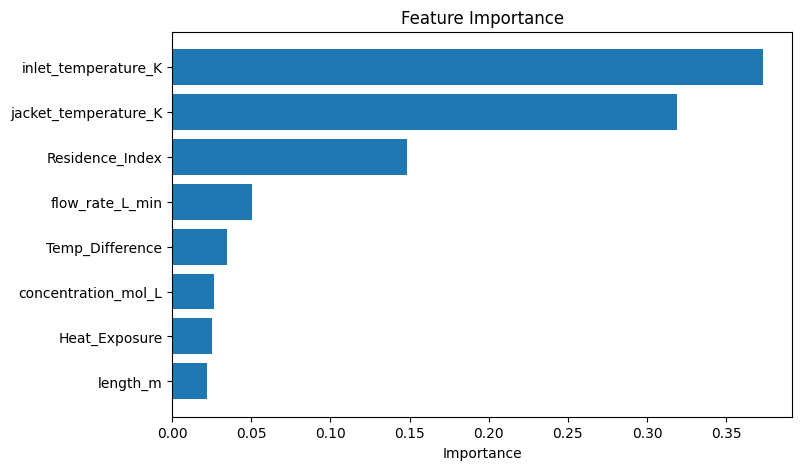

In [48]:
import pandas as pd
import matplotlib.pyplot as plt

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": final_model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance)

plt.figure(figsize=(8,5))
plt.barh(
    importance["Feature"],
    importance["Importance"]
)
plt.xlabel("Importance")
plt.title("Feature Importance")
plt.gca().invert_yaxis()
plt.show()

In [50]:
from sklearn.ensemble import GradientBoostingRegressor

In [51]:
gbr = GradientBoostingRegressor(
    random_state=42
)

In [52]:
gbr.fit(X_train, y_train)

GradientBoostingRegressor(random_state=42)

In [53]:
y_pred_gbr = gbr.predict(X_test)

In [54]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

rmse = np.sqrt(mean_squared_error(y_test, y_pred_gbr))
mae = mean_absolute_error(y_test, y_pred_gbr)
r2 = r2_score(y_test, y_pred_gbr)

print("RMSE :", round(rmse,4))
print("MAE  :", round(mae,4))
print("R²   :", round(r2,4))

RMSE : 23.4087
MAE  : 16.0949
R²   : 0.6884


In [55]:
from sklearn.model_selection import KFold, cross_val_score

kfold = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scores = cross_val_score(
    gbr,
    X,
    y,
    cv=kfold,
    scoring="neg_root_mean_squared_error"
)

rmse_scores = -scores

print(rmse_scores)
print("Average RMSE :", rmse_scores.mean())
print("Std :", rmse_scores.std())

[23.40872957 24.14069589 23.47523396 20.85889836 16.97025435]
Average RMSE : 21.770762425873293
Std : 2.6488155115924363


In [56]:
!pip install xgboost

In [57]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

In [58]:
xgb_model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=4,
    random_state=42
)

In [59]:
xgb_model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, ...)

In [60]:
y_pred = xgb_model.predict(X_test)

In [61]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("RMSE :", round(rmse,4))
print("MAE  :", round(mae,4))
print("R²   :", round(r2,4))

RMSE : 21.4936
MAE  : 12.7362
R²   : 0.7373


In [62]:
from sklearn.model_selection import KFold, cross_val_score

kfold = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scores = cross_val_score(
    xgb_model,
    X,
    y,
    cv=kfold,
    scoring="neg_root_mean_squared_error"
)

rmse_scores = -scores

print("Fold RMSE")

for i, score in enumerate(rmse_scores):
    print(f"Fold {i+1}: {score:.4f}")

print("\nAverage RMSE:", rmse_scores.mean())
print("Std:", rmse_scores.std())

Fold RMSE
Fold 1: 21.4936
Fold 2: 20.4471
Fold 3: 22.8786
Fold 4: 18.1992
Fold 5: 17.6403

Average RMSE: 20.131763065309748
Std: 1.971873393013801


In [63]:
XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=4,
    random_state=42
)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, ...)

In [64]:
from sklearn.model_selection import GridSearchCV
from xgboost import XGBRegressor

param_grid = {
    "n_estimators": [50, 100, 200],
    "max_depth": [3, 4, 5],
    "learning_rate": [0.05, 0.1, 0.2],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0]
}

xgb = XGBRegressor(
    random_state=42,
    objective="reg:squarederror"
)

grid = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

grid.fit(X, y)

print(grid.best_params_)
print(-grid.best_score_)

{'colsample_bytree': 1.0, 'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 200, 'subsample': 0.8}
22.417473866325462


In [66]:
final_model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=4,
    random_state=42
)

final_model.fit(X, y)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, ...)

In [67]:
test_df = pd.read_csv("test_dataset.csv")

In [68]:
test_df.head()

test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   flow_rate_L_min       50 non-null     float64
 1   concentration_mol_L   50 non-null     float64
 2   inlet_temperature_K   50 non-null     float64
 3   length_m              50 non-null     float64
 4   jacket_temperature_K  50 non-null     float64
dtypes: float64(5)
memory usage: 2.1 KB


In [69]:
test_df["Residence_Index"] = (
    test_df["length_m"] /
    test_df["flow_rate_L_min"]
)

test_df["Temp_Difference"] = (
    test_df["jacket_temperature_K"] -
    test_df["inlet_temperature_K"]
)

test_df["Heat_Exposure"] = (
    test_df["Temp_Difference"] *
    test_df["Residence_Index"]
)

In [70]:
feature_columns = [
    "flow_rate_L_min",
    "concentration_mol_L",
    "inlet_temperature_K",
    "jacket_temperature_K",
    "length_m",
    "Residence_Index",
    "Temp_Difference",
    "Heat_Exposure"
]

X_test_final = test_df[feature_columns]

In [73]:
X_test_final = X_test_final[['flow_rate_L_min', 'concentration_mol_L', 'inlet_temperature_K', 'length_m', 'jacket_temperature_K', 'Residence_Index', 'Temp_Difference', 'Heat_Exposure']]
predictions = final_model.predict(X_test_final)

In [74]:
predictions[:10]

array([ 4.0728065e+01,  9.0981621e+01,  2.7929310e+01,  8.5179604e+01,
        1.8497641e+00,  5.9407074e+01,  8.4660591e+01,  6.0137623e+01,
       -7.9262838e-02,  5.4038483e+01], dtype=float32)

In [75]:
submission = pd.DataFrame({
    "overall_yield": predictions
})

In [76]:
submission.to_csv(
    "Log_X.csv",
    index=False
)

In [77]:
submission.shape

(50, 1)

In [78]:
submission.columns

Index(['overall_yield'], dtype='object')

In [79]:
submission.head()

,overall_yield
0,40.728065
1,90.981621
2,27.929310
3,85.179604
4,1.849764


In [80]:
print(submission.shape)

(50, 1)


In [81]:
submission.to_csv("Log_X.csv", index=False)

In [82]:
from google.colab import files

files.download("Log_X.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>